<a href="https://colab.research.google.com/github/smuziVpyze/russian-market-news-analysis/blob/main/04_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 4. Формирование признаков (Feature Engineering)

На четвёртом этапе из сырых данных будут сформированы числовые признаки, готовые к подаче в модели машинного обучения. Признаки разделены на два блока: рыночные и новостные.

## Загрузка данных

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = '/content/drive/MyDrive/russian_market_news_analysis'

# Загружаем дневной сентимент
df_sentiment = pd.read_csv(f'{PROJECT_DIR}/data/processed/daily_sentiment.csv')
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# Загружаем котировки
TICKERS = ['MOEX', 'SBER', 'GAZP', 'LKOH', 'PLZL', 'YDEX']
market_data = {}
for ticker in TICKERS:
    df = pd.read_csv(f'{PROJECT_DIR}/data/raw/market/{ticker}.csv', index_col=0)
    df.index = pd.to_datetime(df.index)
    market_data[ticker] = df

print(f'Сентимент: {len(df_sentiment)} дней')
print(f'Тикеров: {len(market_data)}')

Mounted at /content/drive
Сентимент: 792 дней
Тикеров: 6


## Рыночные признаки

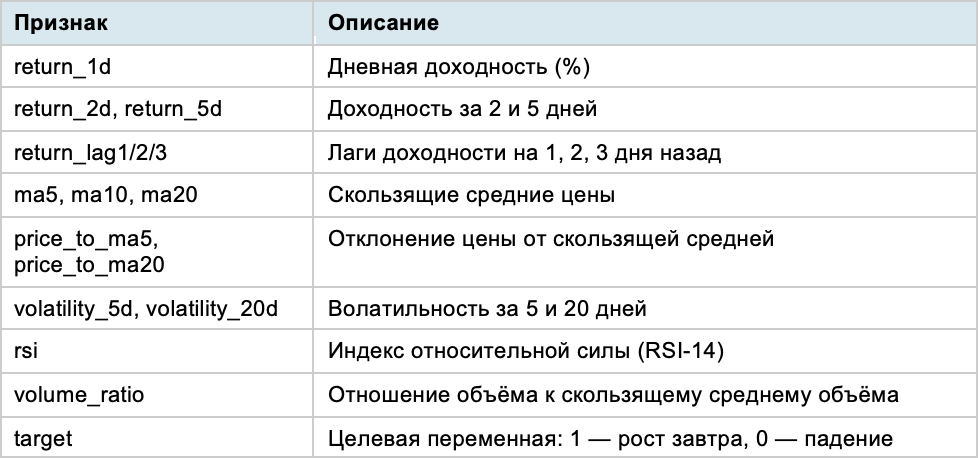

In [2]:
def make_market_features(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    """Создать технические признаки из котировок."""
    d = df.copy()

    # Доходность
    d['return_1d'] = d['close'].pct_change() * 100
    d['return_2d'] = d['close'].pct_change(2) * 100
    d['return_5d'] = d['close'].pct_change(5) * 100

    # Направление движения (целевая переменная)
    d['target'] = (d['return_1d'].shift(-1) > 0).astype(int)

    # Скользящие средние
    d['ma5']  = d['close'].rolling(5).mean()
    d['ma10'] = d['close'].rolling(10).mean()
    d['ma20'] = d['close'].rolling(20).mean()

    # Отклонение цены от MA
    d['price_to_ma5']  = d['close'] / d['ma5'] - 1
    d['price_to_ma20'] = d['close'] / d['ma20'] - 1

    # Волатильность
    d['volatility_5d']  = d['return_1d'].rolling(5).std()
    d['volatility_20d'] = d['return_1d'].rolling(20).std()

    # RSI
    delta = d['close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d['rsi'] = 100 - (100 / (1 + gain / loss.replace(0, 1e-10)))

    # Объём
    if 'volume' in d.columns:
        d['volume_ma5']   = d['volume'].rolling(5).mean()
        d['volume_ratio'] = d['volume'] / d['volume_ma5']

    # Лаги доходности
    for lag in [1, 2, 3]:
        d[f'return_lag{lag}'] = d['return_1d'].shift(lag)

    d['ticker'] = ticker
    d = d.reset_index().rename(columns={'index': 'date', 'begin': 'date'})
    d['date'] = pd.to_datetime(d['date'])

    return d

# Применяем ко всем тикерам
market_features = {}
for ticker, df in market_data.items():
    market_features[ticker] = make_market_features(df, ticker)
    print(f'{ticker}: {len(market_features[ticker])} строк, {market_features[ticker].shape[1]} признаков')

MOEX: 553 строк, 24 признаков
SBER: 553 строк, 24 признаков
GAZP: 553 строк, 24 признаков
LKOH: 553 строк, 24 признаков
PLZL: 553 строк, 24 признаков
YDEX: 526 строк, 24 признаков


## Новостные признаки

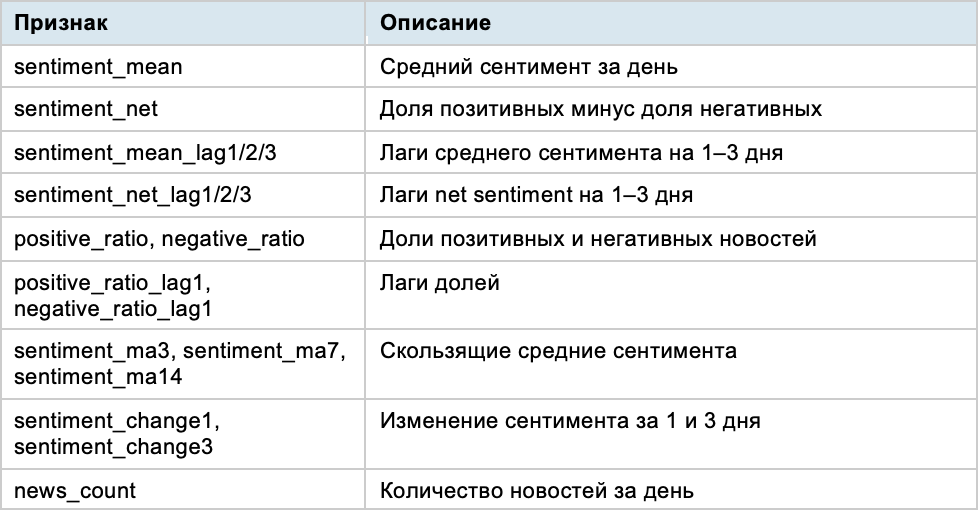

In [3]:
def make_sentiment_features(df_sent: pd.DataFrame) -> pd.DataFrame:
    """Создать признаки тональности с лагами."""
    d = df_sent.copy()

    # Лаги сентимента (0, 1, 2, 3 дня назад)
    for lag in [1, 2, 3]:
        d[f'sentiment_mean_lag{lag}']  = d['sentiment_mean'].shift(lag)
        d[f'sentiment_net_lag{lag}']   = d['sentiment_net'].shift(lag)
        d[f'negative_ratio_lag{lag}']  = d['negative_ratio'].shift(lag)
        d[f'positive_ratio_lag{lag}']  = d['positive_ratio'].shift(lag)
        d[f'news_count_lag{lag}']      = d['news_count'].shift(lag)

    # Скользящие средние сентимента
    d['sentiment_ma3']  = d['sentiment_mean'].rolling(3).mean()
    d['sentiment_ma7']  = d['sentiment_mean'].rolling(7).mean()
    d['sentiment_ma14'] = d['sentiment_mean'].rolling(14).mean()

    # Изменение сентимента
    d['sentiment_change1'] = d['sentiment_mean'].diff(1)
    d['sentiment_change3'] = d['sentiment_mean'].diff(3)

    return d

df_sent_features = make_sentiment_features(df_sentiment)
print(f'Признаков сентимента: {df_sent_features.shape[1]}')
print(f'Дней: {len(df_sent_features)}')

Признаков сентимента: 32
Дней: 792


Важно: при формировании признаков для предсказания следующего дня использовались только лаговые значения сентимента (lag1, lag2, lag3), чтобы исключить утечку данных из будущего. Признак sentiment_mean (текущего дня) использовался только в корреляционном анализе.

## Итоговый датасет

После объединения рыночных и новостных данных по дате был получен финальный датасет:
* Количество признаков: 55 (23 рыночных + 32 новостных)
* Количество строк: ~533 на тикер (после удаления пропусков)
* Баланс классов: ~50/50 для большинства тикеров — балансировка не требуется


In [5]:
# Объединяем для каждого тикера
datasets = {}

for ticker, df_market in market_features.items():
    # Merge по дате
    df_merged = pd.merge(df_market, df_sent_features, on='date', how='inner')

    # Убираем строки с пропусками
    df_merged = df_merged.dropna().reset_index(drop=True)

    datasets[ticker] = df_merged
    print(f'{ticker}: {len(df_merged)} строк, {df_merged.shape[1]} признаков')

print(f'\nПример колонок ({list(datasets.keys())[0]}):')
print(datasets['MOEX'].columns.tolist())

MOEX: 533 строк, 55 признаков
SBER: 533 строк, 55 признаков
GAZP: 533 строк, 55 признаков
LKOH: 533 строк, 55 признаков
PLZL: 533 строк, 55 признаков
YDEX: 506 строк, 55 признаков

Пример колонок (MOEX):
['date', 'open', 'high', 'low', 'close', 'volume', 'return_1d', 'return_2d', 'return_5d', 'target', 'ma5', 'ma10', 'ma20', 'price_to_ma5', 'price_to_ma20', 'volatility_5d', 'volatility_20d', 'rsi', 'volume_ma5', 'volume_ratio', 'return_lag1', 'return_lag2', 'return_lag3', 'ticker', 'news_count', 'sentiment_mean', 'sentiment_std', 'sentiment_max', 'sentiment_min', 'positive_count', 'negative_count', 'neutral_count', 'positive_ratio', 'negative_ratio', 'sentiment_net', 'sentiment_mean_lag1', 'sentiment_net_lag1', 'negative_ratio_lag1', 'positive_ratio_lag1', 'news_count_lag1', 'sentiment_mean_lag2', 'sentiment_net_lag2', 'negative_ratio_lag2', 'positive_ratio_lag2', 'news_count_lag2', 'sentiment_mean_lag3', 'sentiment_net_lag3', 'negative_ratio_lag3', 'positive_ratio_lag3', 'news_count_l

In [6]:
# Сохраняем датасеты
for ticker, df in datasets.items():
    path = f'{PROJECT_DIR}/data/features/{ticker}_features.csv'
    df.to_csv(path, index=False)
    print(f'Сохранён: {ticker}_features.csv')

# Баланс классов (target)
print('\n--- Баланс классов (target) ---')
for ticker, df in datasets.items():
    pos = df['target'].sum()
    neg = len(df) - pos
    pct = pos / len(df) * 100
    print(f'{ticker}: рост={pos} ({pct:.1f}%), падение={neg} ({100-pct:.1f}%)')

Сохранён: MOEX_features.csv
Сохранён: SBER_features.csv
Сохранён: GAZP_features.csv
Сохранён: LKOH_features.csv
Сохранён: PLZL_features.csv
Сохранён: YDEX_features.csv

--- Баланс классов (target) ---
MOEX: рост=271 (50.8%), падение=262 (49.2%)
SBER: рост=290 (54.4%), падение=243 (45.6%)
GAZP: рост=235 (44.1%), падение=298 (55.9%)
LKOH: рост=270 (50.7%), падение=263 (49.3%)
PLZL: рост=274 (51.4%), падение=259 (48.6%)
YDEX: рост=261 (51.6%), падение=245 (48.4%)


In [7]:
print('--- Итог ноутбука 04 ---')
print(f'Тикеров:          {len(datasets)}')
print(f'Признаков:        55')
print(f'Рыночных:         23 (доходности, MA, RSI, волатильность, лаги)')
print(f'Новостных:        32 (сентимент, лаги, скользящие средние)')
print(f'Строк на тикер:   ~533')
print(f'Баланс классов:   ~50/50 — балансировка не нужна')
print(f'\nСледующий шаг: корреляционный анализ → ноутбук 05')

--- Итог ноутбука 04 ---
Тикеров:          6
Признаков:        55
Рыночных:         23 (доходности, MA, RSI, волатильность, лаги)
Новостных:        32 (сентимент, лаги, скользящие средние)
Строк на тикер:   ~533
Баланс классов:   ~50/50 — балансировка не нужна

Следующий шаг: корреляционный анализ → ноутбук 05
